<a href="https://colab.research.google.com/github/Nicky-Georgia/ECG_disease_classification/blob/main/non_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings('ignore')
%pip install kagglehub
#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

path = kagglehub.dataset_download("shayanfazeli/heartbeat")
mitbih_train = pd.read_csv(path + '/mitbih_train.csv')
mitbih_test = pd.read_csv(path + '/mitbih_test.csv')

In [ ]:
%pip install numpy==1.26.0 catboost==1.2.7
import numpy as np

from catboost import CatBoostClassifier

  Using cached numpy-1.26.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (58 kB)
Using cached numpy-1.26.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


Linear model with MSE Loss on pytorch

In [6]:
epoch_count = 150
data_train, data_val = train_test_split(np.array(mitbih_train), test_size= 0.2)
X_train, y_train = data_train[:, :-1], data_train[:, -1].astype(int)

X_val, y_val = data_val[:, :-1], data_val[:, -1].astype(int)
X_test, y_test = np.array(mitbih_test)[:, :-1], np.array(mitbih_test)[:, -1].astype(int)

Basic tree boosting and forest models

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [8]:
model_tree = DecisionTreeClassifier()
model_tree.fit(X_train, y_train)
pred_tree = model_tree.predict(X_test)

report = classification_report(y_test, pred_tree)
print(f"Tree model report:\n{report}")

Tree model report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     18117
           1       0.60      0.61      0.60       556
           2       0.87      0.86      0.87      1448
           3       0.54      0.60      0.57       162
           4       0.93      0.94      0.93      1608

    accuracy                           0.95     21891
   macro avg       0.78      0.79      0.79     21891
weighted avg       0.95      0.95      0.95     21891



In [9]:
model_forest = RandomForestClassifier()
model_forest.fit(X_train, y_train)
pred_forest = model_forest.predict(X_test)

report = classification_report(y_test, pred_forest)
print(f"Forest model report:\n{report}")

Forest model report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18117
           1       0.98      0.59      0.73       556
           2       0.98      0.88      0.93      1448
           3       0.91      0.61      0.73       162
           4       0.99      0.94      0.97      1608

    accuracy                           0.97     21891
   macro avg       0.97      0.80      0.87     21891
weighted avg       0.97      0.97      0.97     21891



In [10]:
model_boost = GradientBoostingClassifier()
model_boost.fit(X_train,y_train)
pred_boost = model_boost.predict(X_test)

report = classification_report(y_test, pred_boost)
print(f"Gradient Boosting model report:\n{report}")

Gradient Boosting model report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18117
           1       0.93      0.56      0.70       556
           2       0.95      0.82      0.88      1448
           3       0.79      0.52      0.63       162
           4       0.98      0.93      0.95      1608

    accuracy                           0.96     21891
   macro avg       0.93      0.76      0.83     21891
weighted avg       0.96      0.96      0.96     21891



Using f1 score because of our class disbalance

In [ ]:
%pip install optuna
from catboost import CatBoostClassifier
import optuna
import seaborn as sns
from sklearn.metrics import f1_score

In [ ]:
def objective_cb_f1(trial):
    param = {
        "iterations": trial.suggest_int("iterations", 100, 1000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.3),
        "random_strength": trial.suggest_loguniform("random_strength", 1e-3, 10.0),
        "bagging_temperature": trial.suggest_loguniform("bagging_temperature", 0.01, 10.0),
        "border_count": trial.suggest_int("border_count", 1, 255),
        "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-3, 10.0),
        "loss_function": "MultiClass",
        "task_type": "GPU",
        "devices": "0:1",
        "verbose": 0,
        "random_seed": 42
    }

    model = CatBoostClassifier(**param)
    model.fit(X_train, y_train, eval_set=(X_test, y_test))

    preds = model.predict(X_test)

    score = f1_score(y_test, preds, average='macro')


    return -score

study_cb = optuna.create_study(direction="minimize")
study_cb.optimize(objective_cb_f1, n_trials=50)

print("Best CatBoost params:", study_cb.best_params)
print("Best CatBoost F1-Score:", -study_cb.best_value)

[I 2025-03-20 12:38:56,718] A new study created in memory with name: no-name-4a721a7f-855a-41ea-bc9b-34041d03760f
[I 2025-03-20 12:39:03,457] Trial 0 finished with value: -0.7893392451402343 and parameters: {'iterations': 307, 'depth': 4, 'learning_rate': 0.11895554321639411, 'random_strength': 0.014511029179315519, 'bagging_temperature': 8.88594525807979, 'border_count': 105, 'l2_leaf_reg': 0.008473053198670335}. Best is trial 0 with value: -0.7893392451402343.
[I 2025-03-20 12:39:26,823] Trial 1 finished with value: -0.8997272331916679 and parameters: {'iterations': 897, 'depth': 9, 'learning_rate': 0.059309680637875326, 'random_strength': 1.8859305804338211, 'bagging_temperature': 0.44749446061951176, 'border_count': 104, 'l2_leaf_reg': 0.0014022218451053576}. Best is trial 1 with value: -0.8997272331916679.
[I 2025-03-20 12:39:35,274] Trial 2 finished with value: -0.8582271240376347 and parameters: {'iterations': 831, 'depth': 6, 'learning_rate': 0.05980043946237484, 'random_streng

Best CatBoost params: {'iterations': 869, 'depth': 9, 'learning_rate': 0.09346318063544509, 'random_strength': 0.009280683817626017, 'bagging_temperature': 0.17225843483572442, 'border_count': 134, 'l2_leaf_reg': 0.9449894803823506}
Best CatBoost F1-Score: 0.9059688097384108



Топ-10 лучших конфигураций по F1-score:



,iterations,depth,learning_rate,random_strength,bagging_temperature,border_count,l2_leaf_reg,F1-Score
19,869,9,0.0935,0.0093,0.1723,134,0.9450,0.9060
25,871,7,0.1003,0.0032,0.0608,118,0.9038,0.9035
22,753,7,0.1706,0.0169,0.0560,147,0.8664,0.9031
13,990,7,0.2926,0.1269,0.0888,52,0.3730,0.9025
44,820,10,0.1007,0.0860,0.0832,83,0.4618,0.9024
41,925,8,0.1704,0.0345,0.0722,143,0.8103,0.9022
42,903,8,0.1774,0.0382,0.0339,146,0.3606,0.9022
21,910,8,0.1755,0.0294,0.0640,144,0.7199,0.9018
46,747,10,0.1220,0.1165,0.4325,47,0.4237,0.9015
11,963,8,0.2937,0.1074,0.1102,84,0.4787,0.9015


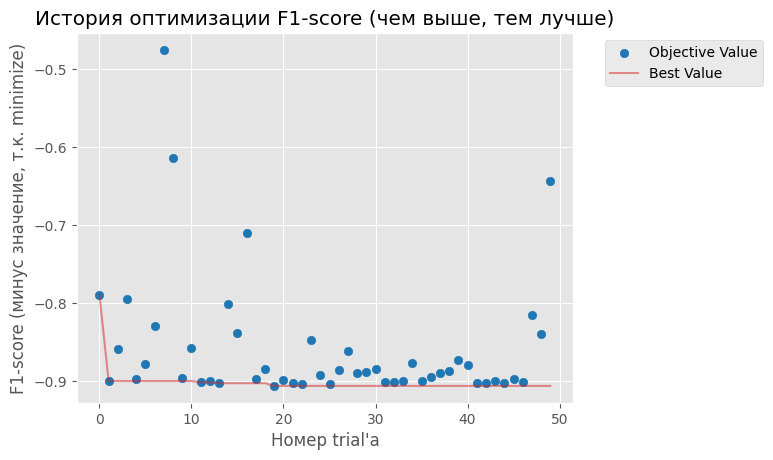

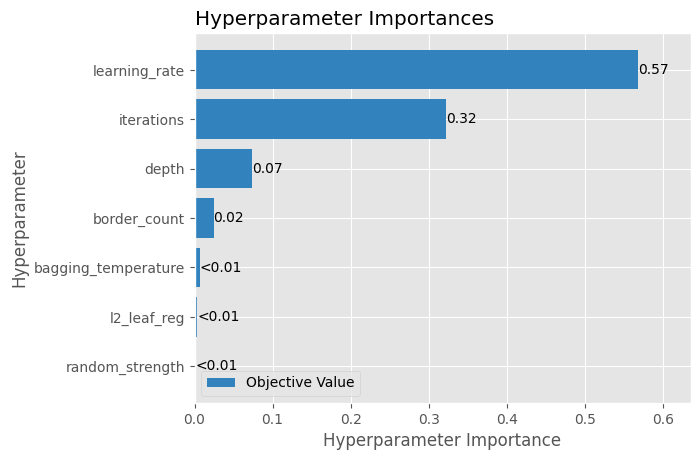

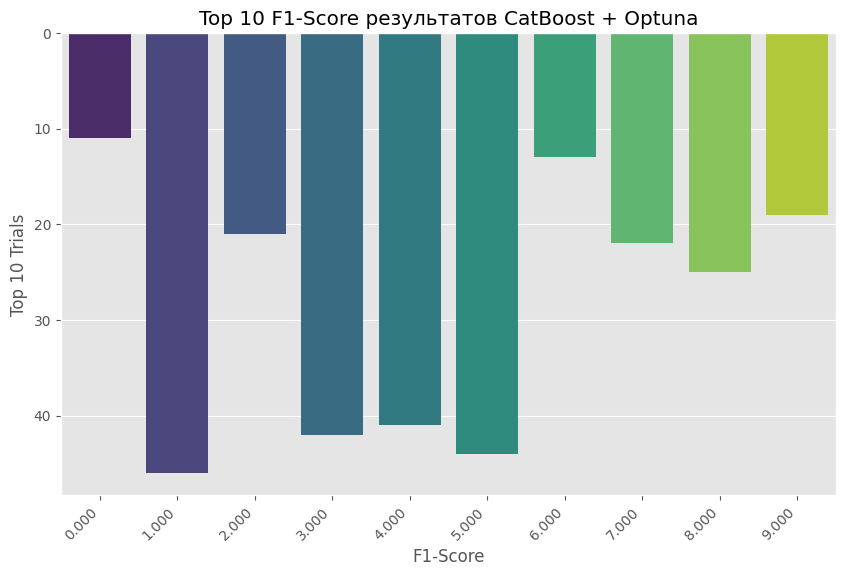

In [ ]:
def plot_optimization_history(study):
    optuna.visualization.matplotlib.plot_optimization_history(study)
    plt.title("История оптимизации F1-score")
    plt.ylabel("F1-score (отрицательное значение)")  # -F1
    plt.xlabel("Номер trial'a")
    plt.show()

def plot_param_importance(study):
    optuna.visualization.matplotlib.plot_param_importances(study)

    plt.show()

def display_top_trials_f1(study, top_n=10):
    trials_df = pd.DataFrame([
        {
            **t.params,
            "F1-Score": -t.value
        }
        for t in study.trials
        if t.value is not None
    ])

    top_trials = trials_df.sort_values(by="F1-Score", ascending=False).head(top_n)

    print(f"\nТоп-{top_n} лучших конфигураций по F1-score:\n")
    display(top_trials.style.background_gradient(cmap="Blues").format(precision=4))

    return top_trials


def plot_top10_f1(top_df):
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_df["Score"], y=top_df.index, palette="viridis")
    plt.xticks(rotation=45, ha="right")


    plt.gca().get_xticklabels()
    plt.gca().set_xticklabels([f"{x:.3f}" for x in plt.gca().get_xticks()])
    plt.xlabel("F1-Score")
    plt.ylabel("Top 10 Trials")
    plt.title("Top 10 F1-Score результатов CatBoost + Optuna")
    plt.gca().invert_yaxis()
    plt.show()


top_10_f1 = display_top_trials_f1(study_cb)


plot_optimization_history(study_cb)
plot_param_importance(study_cb)
plot_top10_f1(top_10_f1.rename(columns={"F1-Score": "Score"}))

In [11]:
%pip install optuna
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 14.1 MB/s eta 0:00:00


In [13]:
def objective_xgb_f1(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_loguniform("reg_alpha", 1e-3, 10.0),
        "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-3, 10.0),
        "gamma": trial.suggest_loguniform("gamma", 1e-3, 10.0),
        "objective": "multi:softmax",
        "num_class": len(set(y_train)),
        "verbosity": 0,
        "random_state": 42,
    }

    model = XGBClassifier(**param)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    preds = model.predict(X_test)
    score = f1_score(y_test, preds, average='macro')

    return -score

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb_f1, n_trials=50)

print("Best XGBoost params:", study_xgb.best_params)
print("Best XGBoost F1-Score:", -study_xgb.best_value)

[I 2025-04-10 10:25:55,585] A new study created in memory with name: no-name-12d6daea-3fea-46ec-b25d-93337e73b9ac
[I 2025-04-10 10:32:18,415] Trial 0 finished with value: -0.8862947759843278 and parameters: {'n_estimators': 669, 'max_depth': 6, 'learning_rate': 0.040535009191506315, 'subsample': 0.8024860987851281, 'colsample_bytree': 0.8993621687380668, 'reg_alpha': 0.05431692220199307, 'reg_lambda': 3.6770213265194656, 'gamma': 1.560451925425722}. Best is trial 0 with value: -0.8862947759843278.
[I 2025-04-10 10:45:36,995] Trial 1 finished with value: -0.9050683603203271 and parameters: {'n_estimators': 980, 'max_depth': 8, 'learning_rate': 0.06386921583940564, 'subsample': 0.730743303948014, 'colsample_bytree': 0.7154641491950945, 'reg_alpha': 0.0035891607130205646, 'reg_lambda': 0.10905077465390887, 'gamma': 0.005405713294671551}. Best is trial 1 with value: -0.9050683603203271.
[I 2025-04-10 10:50:35,936] Trial 2 finished with value: -0.8861621733695573 and parameters: {'n_estimat

Best XGBoost params: {'n_estimators': 343, 'max_depth': 6, 'learning_rate': 0.28586084392864963, 'subsample': 0.933337325928994, 'colsample_bytree': 0.6229576991062298, 'reg_alpha': 0.008965101255486945, 'reg_lambda': 1.5389069714056776, 'gamma': 0.0021126264863443865}
Best XGBoost F1-Score: 0.9097978194138019



Топ-10 лучших конфигураций по F1-score:



,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,reg_alpha,reg_lambda,gamma,F1-Score
18,343,6,0.2859,0.9333,0.6230,0.0090,1.5389,0.0021,0.9098
31,607,6,0.1995,0.9118,0.8858,0.0249,1.2403,0.0142,0.9095
21,335,5,0.2756,0.8672,0.5662,0.0012,2.2607,0.0013,0.9094
26,389,6,0.2104,0.9600,0.5543,0.1010,2.2429,0.0196,0.9082
41,430,6,0.1708,0.6938,0.9077,0.0091,4.9612,0.0426,0.9079
32,420,6,0.1794,0.7804,0.9253,0.0080,5.0904,0.0395,0.9073
42,459,6,0.2085,0.6610,0.8916,0.0099,5.9115,0.0152,0.9068
46,432,6,0.2374,0.6313,0.8106,0.0138,0.8322,0.0551,0.9067
14,603,6,0.2892,0.9151,0.8571,0.0402,1.0015,0.0122,0.9062
40,791,4,0.1328,0.8119,0.5240,0.0253,0.4532,0.0066,0.9062


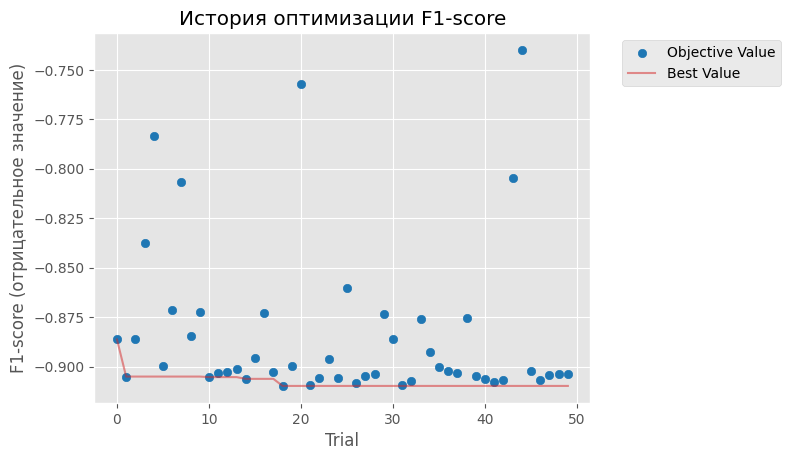

In [15]:
def plot_optimization_history(study):
    optuna.visualization.matplotlib.plot_optimization_history(study)
    plt.title("История оптимизации F1-score")
    plt.ylabel("F1-score (отрицательное значение)")
    plt.show()

def display_top_trials_f1(study, top_n=10):
    trials_df = pd.DataFrame([
        {
            **t.params,
            "F1-Score": -t.value
        }
        for t in study.trials
        if t.value is not None
    ])

    top_trials = trials_df.sort_values(by="F1-Score", ascending=False).head(top_n)

    print(f"\nТоп-{top_n} лучших конфигураций по F1-score:\n")
    display(top_trials.style.background_gradient(cmap="Blues").format(precision=4))

    return top_trials

top_10_f1 = display_top_trials_f1(study_xgb)
print("\n")
plot_optimization_history(study_xgb)